# 03 · EDA, SWH WPP 573 2021–2025

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW  = ROOT / "data" / "raw"
FIG  = ROOT / "output" / "figures" / "eda"
FIG.mkdir(parents=True, exist_ok=True)

WPP = "573"

MUSIM = {12: "Barat", 1: "Barat", 2: "Barat",
         3: "Peralihan I", 4: "Peralihan I", 5: "Peralihan I",
         6: "Timur", 7: "Timur", 8: "Timur",
         9: "Peralihan II", 10: "Peralihan II", 11: "Peralihan II"}
URUT_MUSIM = ["Barat", "Peralihan I", "Timur", "Peralihan II"]

WARNA = {"Barat": "#0072B2", "Peralihan I": "#E69F00",
         "Timur": "#009E73", "Peralihan II": "#CC79A7"}
ABU = "#4d4d4d"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})

def simpan(fig, nama):
    p = FIG / f"{nama}.png"
    fig.savefig(p)
    print("tersimpan:", p.name)

## completeness

In [4]:
berkas = sorted(RAW.glob(f"era5_swh_wpp{WPP}_*.nc"))
print(f"{len(berkas)} berkas:", ", ".join(f.name for f in berkas))

da = (xr.concat([xr.open_dataset(f)["swh"] for f in berkas], dim="valid_time")
        .sortby("valid_time").rename({"valid_time": "waktu"}).load())

waktu = pd.to_datetime(da.waktu.values)
lat, lon = da.latitude.values, da.longitude.values

print(f"\ndimensi   : {dict(da.sizes)}")
print(f"periode   : {waktu.min().date()} s/d {waktu.max().date()}  ({da.sizes['waktu']:,} hari)")
print(f"grid      : {len(lat)} lintang x {len(lon)} bujur, resolusi "
      f"{abs(lat[1]-lat[0]):.2f}° x {abs(lon[1]-lon[0]):.2f}°")
print(f"lintang   : {lat.min():.1f} s/d {lat.max():.1f}   bujur: {lon.min():.1f} s/d {lon.max():.1f}")

5 berkas: era5_swh_wpp573_2021.nc, era5_swh_wpp573_2022.nc, era5_swh_wpp573_2023.nc, era5_swh_wpp573_2024.nc, era5_swh_wpp573_2025.nc

dimensi   : {'waktu': 1826, 'latitude': 17, 'longitude': 49}
periode   : 2021-01-01 s/d 2025-12-31  (1,826 hari)
grid      : 17 lintang x 49 bujur, resolusi 0.50° x 0.50°
lintang   : -15.0 s/d -7.0   bujur: 104.0 s/d 128.0


In [5]:
hari_per_tahun = waktu.year.value_counts().sort_index()
print("hari per tahun:", hari_per_tahun.to_dict())
print("tanggal ganda :", int(pd.Series(waktu).duplicated().sum()))
print("lompatan hari :", int((pd.Series(waktu).diff().dt.days.dropna() != 1).sum()))

n_kosong = da.isnull().sum("waktu").values
laut     = n_kosong == 0
darat    = n_kosong == da.sizes["waktu"]
sebagian = ~laut & ~darat

print(f"\nsel grid      : {laut.size}")
print(f"  laut penuh  : {laut.sum()}")
print(f"  darat penuh : {darat.sum()}")
print(f"  kosong sebagian : {sebagian.sum()}   <- kalau > 0, perlu diselidiki")

hari per tahun: {2021: 365, 2022: 365, 2023: 365, 2024: 366, 2025: 365}
tanggal ganda : 0
lompatan hari : 0

sel grid      : 833
  laut penuh  : 776
  darat penuh : 57
  kosong sebagian : 0   <- kalau > 0, perlu diselidiki


In [6]:
nilai = da.values
mat   = nilai[:, laut]
ii, jj = np.where(laut)
lon_sel, lat_sel = lon[jj], lat[ii]

print(f"matriks kerja: {mat.shape[0]:,} hari x {mat.shape[1]} sel laut "
      f"= {mat.size:,} pengamatan sel-hari")
print(f"nilai hilang : {np.isnan(mat).sum()}")

matriks kerja: 1,826 hari x 776 sel laut = 1,416,976 pengamatan sel-hari
nilai hilang : 0


## descriptive stats

In [7]:
flat = mat.ravel()
ringkas_selhari = pd.Series(flat).describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99])

hari = pd.DataFrame({
    "tanggal": waktu,
    "indeks":  np.nanmean(mat, axis=1),
    "sel_maks": np.nanmax(mat, axis=1),
    "sel_min":  np.nanmin(mat, axis=1),
})
hari["tahun"] = hari.tanggal.dt.year
hari["bulan"] = hari.tanggal.dt.month
hari["musim"] = hari.bulan.map(MUSIM)

tab = pd.concat([ringkas_selhari.rename("sel-hari"),
                 hari.indeks.describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99])
                     .rename("indeks area")], axis=1)
print(tab.round(3).to_string())
print(f"\nkemencengan (skewness) sel-hari : {stats.skew(flat):.3f}")
print(f"keruncingan (excess kurtosis)    : {stats.kurtosis(flat):.3f}")

          sel-hari  indeks area
count  1416976.000     1826.000
mean         1.679        1.679
std          0.811        0.386
min          0.058        0.843
1%           0.224        0.964
5%           0.409        1.121
25%          1.035        1.404
50%          1.705        1.627
75%          2.232        1.927
90%          2.714        2.190
95%          3.013        2.360
99%          3.610        2.708
max          9.277        3.356

kemencengan (skewness) sel-hari : 0.265
keruncingan (excess kurtosis)    : -0.037


## time series + seasonality

tersimpan: eda_01_deret_waktu.png


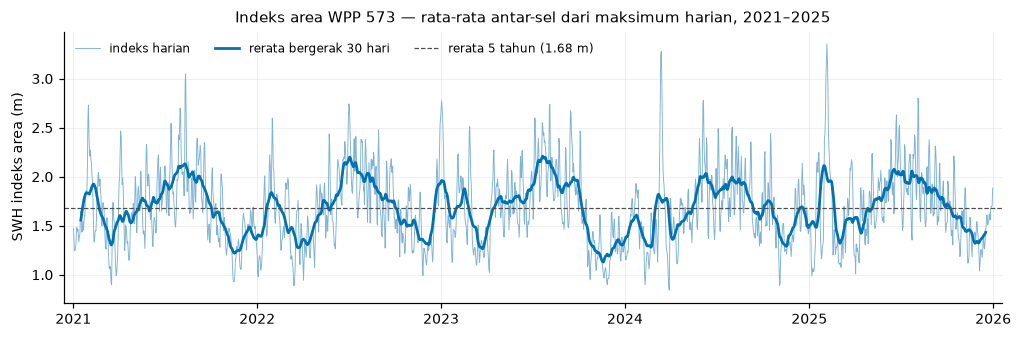

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(hari.tanggal, hari.indeks, lw=0.6, color="#7fb3d5", label="indeks harian")
ax.plot(hari.tanggal, hari.indeks.rolling(30, center=True).mean(),
        lw=1.8, color="#0072B2", label="rerata bergerak 30 hari")
ax.axhline(hari.indeks.mean(), lw=0.8, ls="--", color=ABU, label=f"rerata 5 tahun ({hari.indeks.mean():.2f} m)")
ax.set_ylabel("SWH indeks area (m)")
ax.set_title(f"Indeks area WPP {WPP} — rata-rata antar-sel dari maksimum harian, 2021–2025")
ax.legend(loc="upper left", ncol=3, fontsize=8)
ax.margins(x=0.01)
simpan(fig, "eda_01_deret_waktu"); plt.show()

tersimpan: eda_02_siklus_musiman.png


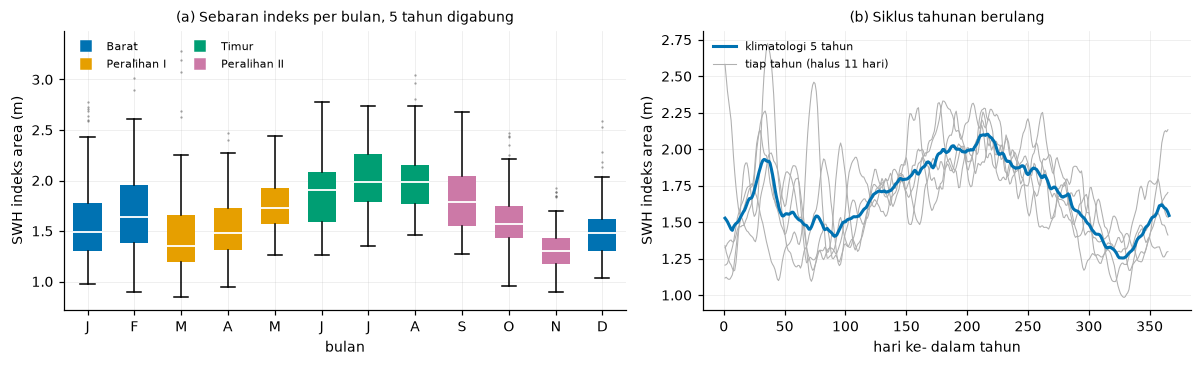

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1.15, 1]})

data_bln = [hari.loc[hari.bulan == b, "indeks"].values for b in range(1, 13)]
bp = ax[0].boxplot(data_bln, tick_labels=list("JFMAMJJASOND"), widths=0.6,
                   patch_artist=True, medianprops=dict(color="white", lw=1.2),
                   flierprops=dict(marker=".", ms=3, mfc=ABU, mec="none", alpha=.5))
for b, patch in zip(range(1, 13), bp["boxes"]):
    patch.set_facecolor(WARNA[MUSIM[b]]); patch.set_edgecolor("none")
ax[0].set_ylabel("SWH indeks area (m)"); ax[0].set_xlabel("bulan")
ax[0].set_title("(a) Sebaran indeks per bulan, 5 tahun digabung", fontsize=9)
tangan = [plt.Line2D([], [], marker="s", ls="", ms=7, color=WARNA[m], label=m) for m in URUT_MUSIM]
ax[0].legend(handles=tangan, fontsize=7.5, loc="upper left", ncol=2)

doy = hari.tanggal.dt.dayofyear
for th in sorted(hari.tahun.unique()):
    m = hari.tahun == th
    ax[1].plot(doy[m], hari.indeks[m].rolling(11, center=True, min_periods=1).mean(),
               lw=0.7, color="#b0b0b0")
klim = hari.groupby(doy.values).indeks.mean()
klim_halus = pd.concat([klim, klim, klim]).rolling(15, center=True).mean().iloc[len(klim):2*len(klim)]
ax[1].plot(klim.index, klim_halus.values, lw=2, color="#0072B2", label="klimatologi 5 tahun")
ax[1].plot([], [], lw=0.7, color="#b0b0b0", label="tiap tahun (halus 11 hari)")
ax[1].set_xlabel("hari ke- dalam tahun"); ax[1].set_ylabel("SWH indeks area (m)")
ax[1].set_title("(b) Siklus tahunan berulang", fontsize=9)
ax[1].legend(fontsize=7.5, loc="upper left")

fig.tight_layout(); simpan(fig, "eda_02_siklus_musiman"); plt.show()

In [10]:
print("Statistik indeks per bulan:")
g = hari.groupby("bulan").indeks.agg(["mean", "std", "min", "max"])
g["cv"] = g["std"] / g["mean"]
print(g.round(3).to_string())

print("\nStatistik indeks per musim:")
print(hari.groupby("musim").indeks.agg(["mean", "std", "min", "max", "count"])
        .reindex(URUT_MUSIM).round(3).to_string())

Statistik indeks per bulan:
        mean    std    min    max     cv
bulan                                   
1      1.586  0.394  0.979  2.775  0.248
2      1.717  0.460  0.899  3.356  0.268
3      1.470  0.420  0.843  3.278  0.285
4      1.530  0.300  0.944  2.466  0.196
5      1.751  0.235  1.267  2.437  0.134
6      1.876  0.323  1.265  2.780  0.172
7      2.012  0.311  1.354  2.742  0.155
8      1.986  0.307  1.456  3.049  0.154
9      1.809  0.311  1.273  2.674  0.172
10     1.600  0.278  0.953  2.466  0.174
11     1.308  0.220  0.892  1.924  0.168
12     1.501  0.270  1.033  2.589  0.180

Statistik indeks per musim:
               mean    std    min    max  count
musim                                          
Barat         1.598  0.389  0.899  3.356    451
Peralihan I   1.585  0.349  0.843  3.278    460
Timur         1.959  0.318  1.265  3.049    460
Peralihan II  1.573  0.340  0.892  2.674    455


tersimpan: eda_03_heatmap_tahun_bulan.png


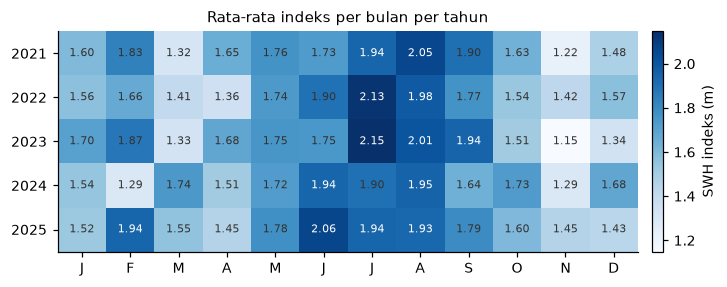

In [11]:
piv = hari.pivot_table(index="tahun", columns="bulan", values="indeks", aggfunc="mean")
fig, ax = plt.subplots(figsize=(8.2, 2.6))
im = ax.imshow(piv.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(12), list("JFMAMJJASOND")); ax.set_yticks(range(len(piv)), piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="white" if v > piv.values.mean() + 0.25 else "#333333")
fig.colorbar(im, ax=ax, label="SWH indeks (m)", pad=0.02)
ax.set_title("Rata-rata indeks per bulan per tahun", fontsize=10); ax.grid(False)
simpan(fig, "eda_03_heatmap_tahun_bulan"); plt.show()

## spatial pattern

In [12]:
sel_rata = np.nanmean(mat, axis=0)
sel_sd   = np.nanstd(mat, axis=0)
sel_p99  = np.nanpercentile(mat, 99, axis=0)
sel_maks = np.nanmax(mat, axis=0)
sel_cv   = sel_sd / sel_rata

m_barat = (hari.musim == "Barat").values
m_timur = (hari.musim == "Timur").values
sel_amp = mat[m_timur].mean(axis=0) - mat[m_barat].mean(axis=0)

sel = pd.DataFrame({"lon": lon_sel, "lat": lat_sel, "rata": sel_rata, "sd": sel_sd,
                    "cv": sel_cv, "p99": sel_p99, "maks": sel_maks, "amp": sel_amp})
print(sel[["rata", "sd", "cv", "p99", "maks", "amp"]].describe().round(2).to_string())

         rata      sd      cv     p99    maks     amp
count  776.00  776.00  776.00  776.00  776.00  776.00
mean     1.68    0.49    0.33    3.11    4.66    0.36
std      0.64    0.10    0.12    0.81    1.58    0.31
min      0.21    0.09    0.23    0.47    0.66   -0.36
25%      1.11    0.45    0.25    2.72    3.68    0.11
50%      1.91    0.51    0.26    3.34    4.56    0.44
75%      2.23    0.56    0.40    3.71    5.73    0.61
max      2.56    0.64    0.75    4.26    9.28    0.87


tersimpan: eda_04_peta_spasial.png


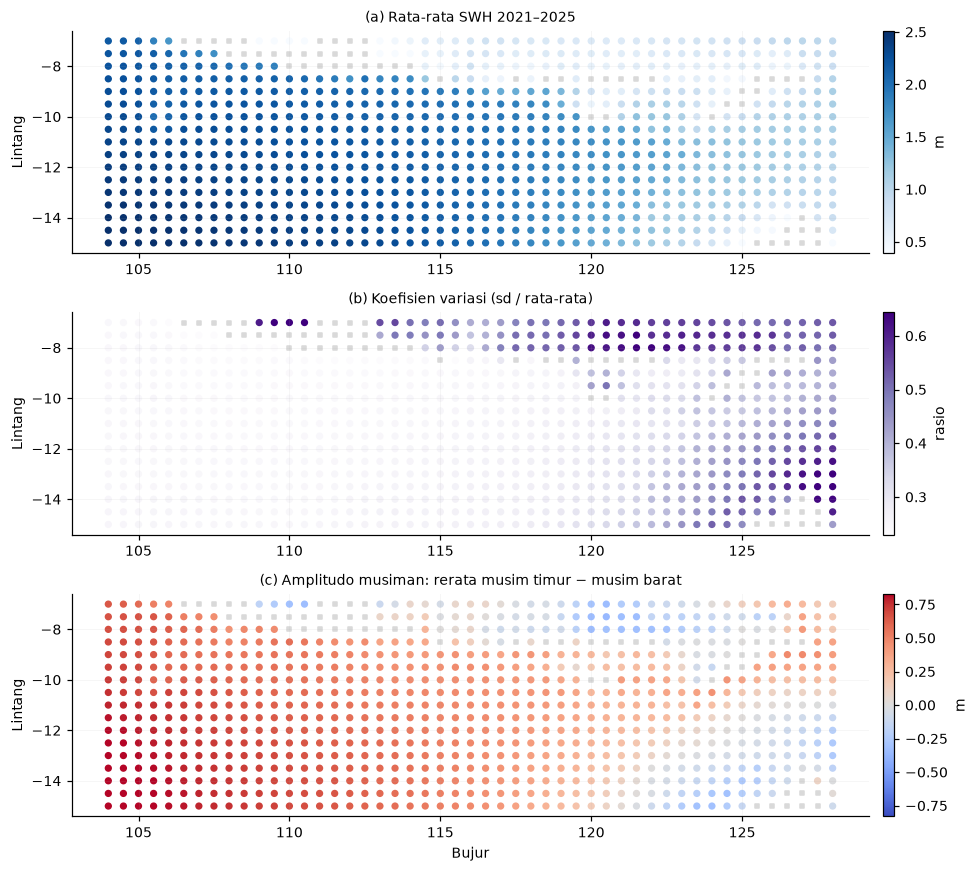

In [13]:
def peta(ax, nilai_sel, judul, cmap, label, simetris=False):
    if simetris:
        b = np.percentile(np.abs(nilai_sel), 98)
        sc = ax.scatter(lon_sel, lat_sel, c=nilai_sel, s=14, cmap=cmap, vmin=-b, vmax=b)
    else:
        lo_v, hi_v = np.percentile(nilai_sel, [1, 99])
        sc = ax.scatter(lon_sel, lat_sel, c=nilai_sel, s=14, cmap=cmap, vmin=lo_v, vmax=hi_v)
    ax.scatter(lon[np.where(darat)[1]], lat[np.where(darat)[0]], s=10, color="#d9d9d9", marker="s")
    fig.colorbar(sc, ax=ax, label=label, pad=0.015)
    ax.set_title(judul, fontsize=9); ax.set_ylabel("Lintang"); ax.grid(alpha=0.15)

fig, ax = plt.subplots(3, 1, figsize=(9.5, 8))
peta(ax[0], sel_rata, "(a) Rata-rata SWH 2021–2025", "Blues", "m")
peta(ax[1], sel_cv,   "(b) Koefisien variasi (sd / rata-rata)", "Purples", "rasio")
peta(ax[2], sel_amp,  "(c) Amplitudo musiman: rerata musim timur − musim barat",
     "coolwarm", "m", simetris=True)
ax[2].set_xlabel("Bujur")
fig.tight_layout(); simpan(fig, "eda_04_peta_spasial"); plt.show()

tersimpan: eda_05_gradien_bujur.png


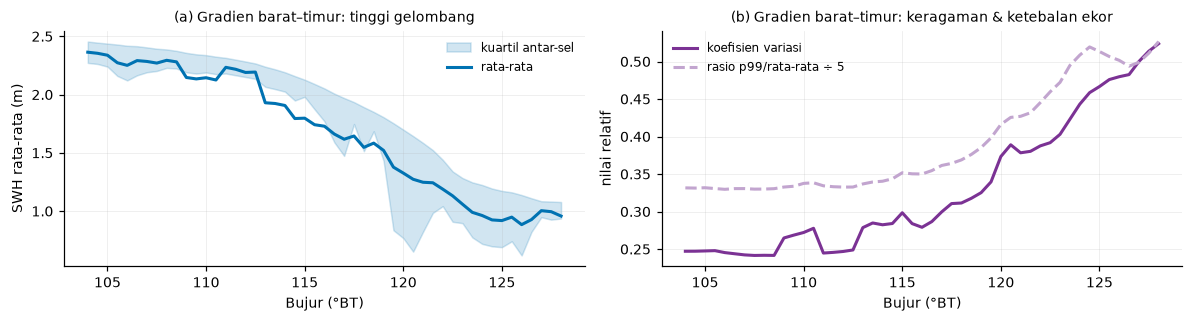

       rata   q25   q75    cv  rasio
lon                                 
104.0  2.36  2.27  2.46  0.25   1.66
107.0  2.28  2.19  2.41  0.24   1.65
110.0  2.14  2.19  2.34  0.27   1.69
113.0  1.93  2.07  2.24  0.28   1.68
116.0  1.73  1.77  2.05  0.28   1.75
119.0  1.52  1.43  1.81  0.33   1.93
122.0  1.19  1.04  1.44  0.39   2.23
125.0  0.92  0.69  1.17  0.47   2.57
128.0  0.96  0.94  1.08  0.52   2.63


In [14]:
prof = sel.groupby("lon").agg(rata=("rata", "mean"), q25=("rata", lambda s: s.quantile(.25)),
                              q75=("rata", lambda s: s.quantile(.75)), cv=("cv", "mean"),
                              rasio=("p99", "mean"))
prof["rasio"] = prof["rasio"] / prof["rata"]

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].fill_between(prof.index, prof.q25, prof.q75, color="#0072B2", alpha=.18, label="kuartil antar-sel")
ax[0].plot(prof.index, prof.rata, lw=2, color="#0072B2", label="rata-rata")
ax[0].set_xlabel("Bujur (°BT)"); ax[0].set_ylabel("SWH rata-rata (m)")
ax[0].set_title("(a) Gradien barat–timur: tinggi gelombang", fontsize=9); ax[0].legend(fontsize=8)

ax[1].plot(prof.index, prof.cv, lw=2, color="#7b3294", label="koefisien variasi")
ax[1].plot(prof.index, prof.rasio / 5, lw=2, ls="--", color="#c2a5cf", label="rasio p99/rata-rata ÷ 5")
ax[1].set_xlabel("Bujur (°BT)"); ax[1].set_ylabel("nilai relatif")
ax[1].set_title("(b) Gradien barat–timur: keragaman & ketebalan ekor", fontsize=9)
ax[1].legend(fontsize=8)

fig.tight_layout(); simpan(fig, "eda_05_gradien_bujur"); plt.show()

print(prof.round(2).iloc[::6].to_string())

## distribution

tersimpan: eda_06_sebaran.png


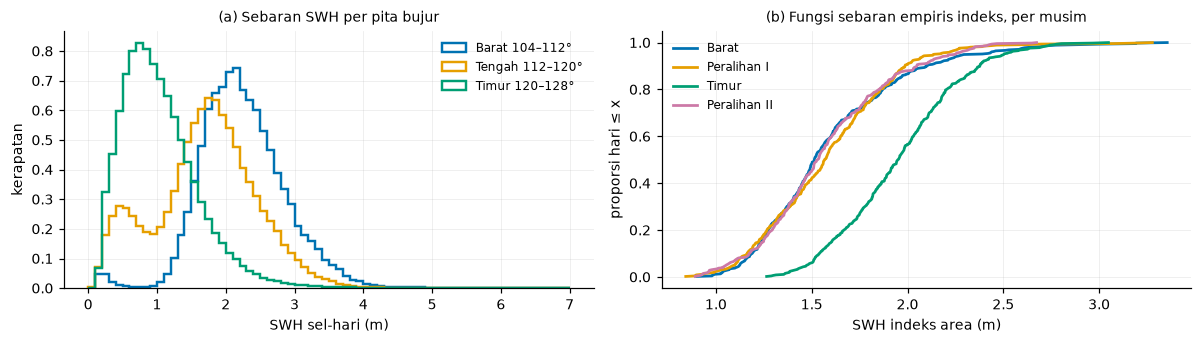

In [15]:
pita = pd.cut(sel.lon, [103.9, 112, 120, 128.1], labels=["Barat 104–112°", "Tengah 112–120°", "Timur 120–128°"])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))

for nama, warna in zip(pita.cat.categories, ["#0072B2", "#E69F00", "#009E73"]):
    kol = np.flatnonzero((pita == nama).values)
    ax[0].hist(mat[:, kol].ravel(), bins=70, range=(0, 7), density=True,
               histtype="step", lw=1.6, color=warna, label=nama)
ax[0].set_xlabel("SWH sel-hari (m)"); ax[0].set_ylabel("kerapatan")
ax[0].set_title("(a) Sebaran SWH per pita bujur", fontsize=9); ax[0].legend(fontsize=8)

for m in URUT_MUSIM:
    x = np.sort(hari.loc[hari.musim == m, "indeks"].values)
    ax[1].plot(x, np.arange(1, len(x)+1)/len(x), lw=1.8, color=WARNA[m], label=m)
ax[1].set_xlabel("SWH indeks area (m)"); ax[1].set_ylabel("proporsi hari ≤ x")
ax[1].set_title("(b) Fungsi sebaran empiris indeks, per musim", fontsize=9); ax[1].legend(fontsize=8)

fig.tight_layout(); simpan(fig, "eda_06_sebaran"); plt.show()

In [16]:
ring = []
for nama in pita.cat.categories:
    kol = np.flatnonzero((pita == nama).values)
    x = mat[:, kol].ravel()
    ring.append({"pita": nama, "n_sel": len(kol), "rata": x.mean(), "median": np.median(x),
                 "sd": x.std(), "cv": x.std()/x.mean(), "skew": stats.skew(x),
                 "kurt": stats.kurtosis(x), "p99": np.percentile(x, 99), "maks": x.max()})
print(pd.DataFrame(ring).round(2).to_string(index=False))

           pita  n_sel  rata  median   sd   cv  skew  kurt  p99  maks
 Barat 104–112°    267  2.25    2.20 0.62 0.28  0.35  2.39 3.86  8.49
Tengah 112–120°    260  1.70    1.74 0.74 0.44  0.08  0.37 3.44  9.28
 Timur 120–128°    249  1.04    0.95 0.55 0.53  1.20  2.77 2.77  6.42


## year to year

tersimpan: eda_07_antar_tahun.png


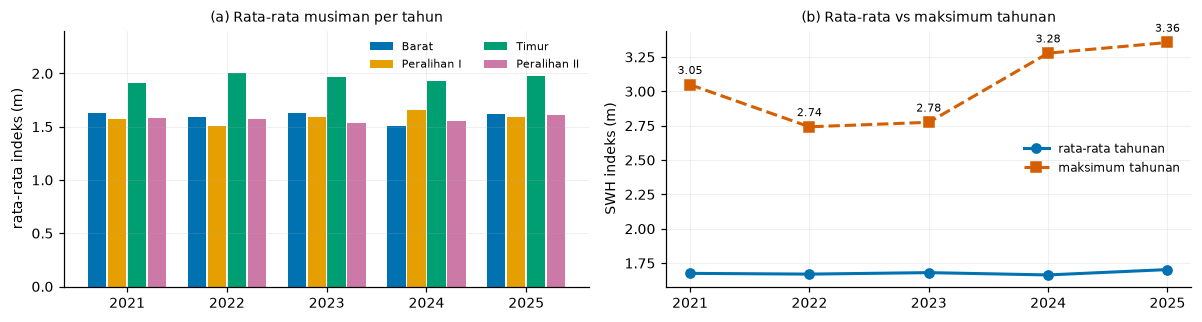

        mean    std    max
tahun                     
2021   1.676  0.372  3.049
2022   1.671  0.377  2.742
2023   1.681  0.410  2.775
2024   1.665  0.371  3.278
2025   1.704  0.398  3.356

simpangan baku rata-rata tahunan : 0.0150 m (0.9% dari rata-rata)
rentang maksimum tahunan        : 2.74 – 3.36 m (22% selisih)


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))

pmt = hari.pivot_table(index="tahun", columns="musim", values="indeks", aggfunc="mean")[URUT_MUSIM]
x = np.arange(len(pmt)); w = 0.2
for k, m in enumerate(URUT_MUSIM):
    ax[0].bar(x + (k - 1.5)*w, pmt[m], w*0.92, color=WARNA[m], label=m)
ax[0].set_xticks(x, pmt.index); ax[0].set_ylabel("rata-rata indeks (m)")
ax[0].set_title("(a) Rata-rata musiman per tahun", fontsize=9)
ax[0].legend(fontsize=7.5, ncol=2); ax[0].set_ylim(0, 2.4)

tahunan = hari.groupby("tahun").indeks.agg(["mean", "max"])
ax[1].plot(tahunan.index, tahunan["mean"], "o-", lw=2, ms=6, color="#0072B2", label="rata-rata tahunan")
ax[1].plot(tahunan.index, tahunan["max"], "s--", lw=2, ms=6, color="#d55e00", label="maksimum tahunan")
for t, v in tahunan["max"].items():
    ax[1].annotate(f"{v:.2f}", (t, v), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=7.5)
ax[1].set_xticks(tahunan.index); ax[1].set_ylabel("SWH indeks (m)")
ax[1].set_title("(b) Rata-rata vs maksimum tahunan", fontsize=9); ax[1].legend(fontsize=8)

fig.tight_layout(); simpan(fig, "eda_07_antar_tahun"); plt.show()

print(hari.groupby("tahun").indeks.agg(["mean", "std", "max"]).round(3).to_string())
print(f"\nsimpangan baku rata-rata tahunan : {tahunan['mean'].std():.4f} m "
      f"({tahunan['mean'].std()/tahunan['mean'].mean()*100:.1f}% dari rata-rata)")
print(f"rentang maksimum tahunan        : {tahunan['max'].min():.2f} – {tahunan['max'].max():.2f} m "
      f"({(tahunan['max'].max()/tahunan['max'].min()-1)*100:.0f}% selisih)")

## extremes

tersimpan: eda_08_ekstrem.png


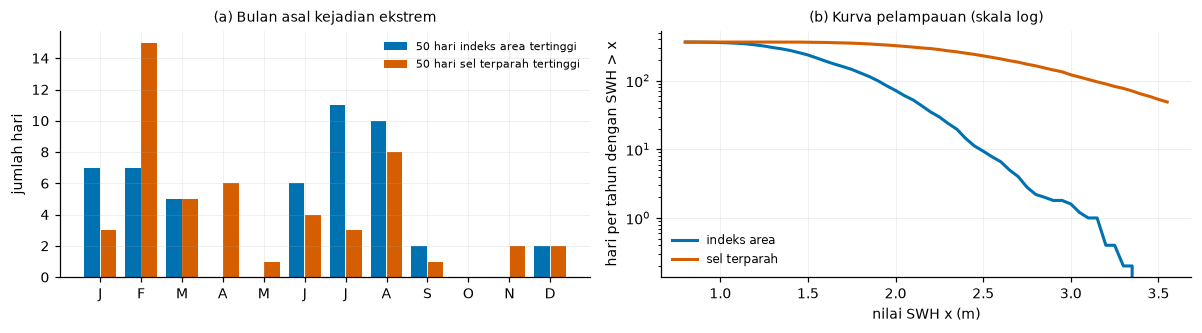

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.1))

top_idx = hari.nlargest(50, "indeks").bulan.value_counts().reindex(range(1, 13), fill_value=0)
top_sel = hari.nlargest(50, "sel_maks").bulan.value_counts().reindex(range(1, 13), fill_value=0)
xb = np.arange(12)
ax[0].bar(xb - 0.2, top_idx.values, 0.38, color="#0072B2", label="50 hari indeks area tertinggi")
ax[0].bar(xb + 0.2, top_sel.values, 0.38, color="#d55e00", label="50 hari sel terparah tertinggi")
ax[0].set_xticks(xb, list("JFMAMJJASOND")); ax[0].set_ylabel("jumlah hari")
ax[0].set_title("(a) Bulan asal kejadian ekstrem", fontsize=9); ax[0].legend(fontsize=7.5)

amb = np.arange(0.8, 3.6, 0.05)
ax[1].plot(amb, [(hari.indeks > u).sum()/5 for u in amb], lw=2, color="#0072B2", label="indeks area")
ax[1].plot(amb, [(hari.sel_maks > u).sum()/5 for u in amb], lw=2, color="#d55e00", label="sel terparah")
ax[1].set_yscale("log"); ax[1].set_xlabel("nilai SWH x (m)")
ax[1].set_ylabel("hari per tahun dengan SWH > x")
ax[1].set_title("(b) Kurva pelampauan (skala log)", fontsize=9); ax[1].legend(fontsize=8)

fig.tight_layout(); simpan(fig, "eda_08_ekstrem"); plt.show()

In [19]:
print("10 hari dengan indeks area tertinggi:")
print(hari.nlargest(10, "indeks")[["tanggal", "musim", "indeks", "sel_maks"]]
        .assign(tanggal=lambda d: d.tanggal.dt.date).round(2).to_string(index=False))

k = int(np.nanargmax(mat.max(axis=0)))
h_max = int(np.nanargmax(mat[:, k]))
print(f"\nnilai sel tertinggi seluruh periode: {mat[h_max, k]:.2f} m "
      f"pada {waktu[h_max].date()}, di {lat_sel[k]:.1f}° LS / {lon_sel[k]:.1f}° BT")

10 hari dengan indeks area tertinggi:
   tanggal       musim  indeks  sel_maks
2025-02-05       Barat    3.36      8.49
2024-03-13 Peralihan I    3.28      6.74
2024-03-12 Peralihan I    3.20      7.19
2025-02-06       Barat    3.19      7.77
2025-02-04       Barat    3.19      9.28
2024-03-14 Peralihan I    3.08      5.75
2021-08-12       Timur    3.05      5.02
2025-02-03       Barat    3.01      8.09
2021-08-11       Timur    2.97      5.31
2025-02-07       Barat    2.90      5.62

nilai sel tertinggi seluruh periode: 9.28 m pada 2025-02-04, di -14.5° LS / 112.5° BT


## persistence

tersimpan: eda_09_autokorelasi.png


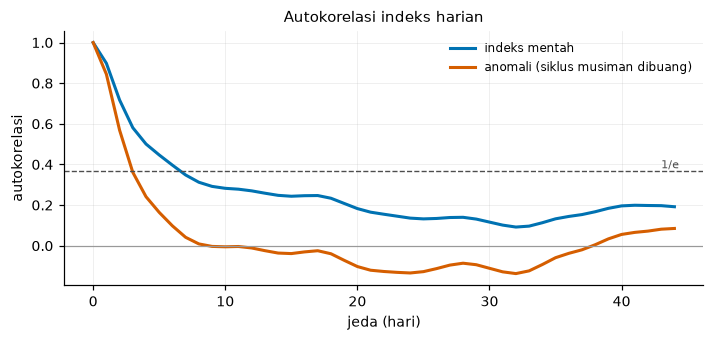

autokorelasi anomali lag 1–7 : [0.84 0.57 0.36 0.24 0.16 0.1  0.04]
waktu peluruhan (lag pertama < 1/e) : 3 hari
proporsi ragam yang dijelaskan siklus musiman : 35%


In [20]:
s = hari.indeks.values
doy = hari.tanggal.dt.dayofyear.values
klim_map = pd.Series(klim_halus.values, index=klim.index)
anom = s - klim_map.reindex(doy).values

def acf(x, n=45):
    x = x - np.nanmean(x); v = np.nansum(x*x)
    return np.array([np.nansum(x[:len(x)-k] * x[k:]) / v for k in range(n)])

a_mentah, a_anom = acf(s), acf(anom)

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.plot(a_mentah, lw=2, color="#0072B2", label="indeks mentah")
ax.plot(a_anom, lw=2, color="#d55e00", label="anomali (siklus musiman dibuang)")
ax.axhline(1/np.e, ls="--", lw=0.9, color=ABU); ax.axhline(0, lw=0.8, color="#999999")
ax.annotate("1/e", (43, 1/np.e), fontsize=7.5, va="bottom", color=ABU)
ax.set_xlabel("jeda (hari)"); ax.set_ylabel("autokorelasi")
ax.set_title("Autokorelasi indeks harian", fontsize=10); ax.legend(fontsize=8)
simpan(fig, "eda_09_autokorelasi"); plt.show()

efold = int(np.argmax(a_anom < 1/np.e))
print(f"autokorelasi anomali lag 1–7 : {np.round(a_anom[1:8], 2)}")
print(f"waktu peluruhan (lag pertama < 1/e) : {efold} hari")
print(f"proporsi ragam yang dijelaskan siklus musiman : "
      f"{(1 - np.nanvar(anom)/np.nanvar(s))*100:.0f}%")

## spatial correlation

tersimpan: eda_10_korelasi_spasial.png


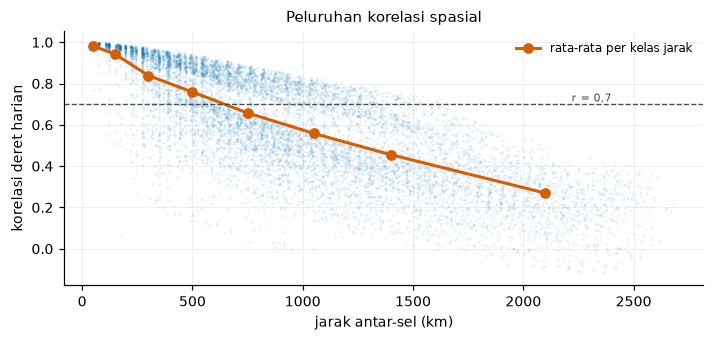

              mean  count
d                        
(0, 100]      0.98    107
(100, 200]    0.94    426
(200, 400]    0.84   1326
(400, 600]    0.76   1556
(600, 900]    0.66   2302
(900, 1200]   0.56   1799
(1200, 1600]  0.46   1747
(1600, 2600]  0.27   1905

lebar WPP 573 (barat–timur): ~2615 km


In [21]:
rng = np.random.default_rng(0)
pilih = rng.choice(mat.shape[1], 150, replace=False)
Ck = np.corrcoef(mat[:, pilih].T)
la, lo_ = lat_sel[pilih], lon_sel[pilih]
D = np.sqrt(((la[:, None]-la[None, :])*111)**2 +
            ((lo_[:, None]-lo_[None, :])*111*np.cos(np.radians(la[:, None])))**2)
iu = np.triu_indices(len(pilih), 1)
jarak, korel = D[iu], Ck[iu]

kotak = pd.cut(jarak, [0, 100, 200, 400, 600, 900, 1200, 1600, 2600])
binned = pd.DataFrame({"d": kotak, "r": korel}).groupby("d", observed=True).r.mean()

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.scatter(jarak, korel, s=3, alpha=.08, color="#0072B2", edgecolors="none")
ax.plot([i.mid for i in binned.index], binned.values, "o-", lw=2, ms=6, color="#d55e00",
        label="rata-rata per kelas jarak")
ax.axhline(0.7, ls="--", lw=0.9, color=ABU)
ax.annotate("r = 0,7", (2400, 0.7), fontsize=7.5, va="bottom", ha="right", color=ABU)
ax.set_xlabel("jarak antar-sel (km)"); ax.set_ylabel("korelasi deret harian")
ax.set_title("Peluruhan korelasi spasial", fontsize=10); ax.legend(fontsize=8)
simpan(fig, "eda_10_korelasi_spasial"); plt.show()

print(pd.DataFrame({"d": kotak, "r": korel}).groupby("d", observed=True).r
        .agg(["mean", "count"]).round(2).to_string())
print(f"\nlebar WPP 573 (barat–timur): ~{(128-104)*111*np.cos(np.radians(11)):.0f} km")